# Conceptual Captions (CC3M): EDA before cleaning → preprocessing → EDA after cleaning → COCO vs CC

**About the dataset** (Sharma et al., ACL 2018):
- **What it is:** image + caption pairs taken from the alt-text of web images, heavily filtered and "hypernymised" (names replaced by generic words, e.g. *Harrison Ford → actor*).
- **Splits:** train 3,318,333 · validation 15,840 · test ~12.5K (hidden).
- **Format:** one caption per image. Only image URLs are distributed, and many have died since 2018.

**Data used here:** built by `prepare_cc.py`.
- the **validation** set: all 15,840 captions, plus the images that could still be downloaded
- a fixed random sample of **300,000 train captions** (text only) for statistics
- **all 3.3M train captions**, streamed, for the vocabulary

| Part | What it does |
|---|---|
| **A** | Raw EDA: download outcome, text statistics, image statistics |
| **B** | Preprocessing: CC's own pipeline (text) + the same image pipeline as COCO |
| **C** | Clean EDA: same statistics after preprocessing |
| **D** | Before vs after comparison |
| **E** | COCO vs CC: the domain gap in numbers |

The analysis functions are shared with the COCO notebook (`eda/eda_utils.py`), so all numbers are directly comparable.

In [1]:
import json, re, random, sys, textwrap, unicodedata, warnings, math
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
sys.path.insert(0, str(ROOT / "eda"))
from eda_utils import (STOP, savefig, known_word, pct, norm_form, text_stats, char_stats, show_text_stats, plot_rare,
                       image_pass, find_duplicates, show_images, CLIP_MEAN, CLIP_STD, IMAGENET_MEAN, IMAGENET_STD, SIZE,
                       resize_shorter, center_crop, eval_transform, random_resized_crop)

DATA = ROOT / "data"
CC = DATA / "cc"
VAL = CC / "val"
COCO = DATA / "coco"
ANALYSIS = CC / "analysis"
ANALYSIS.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = random.Random(SEED)
N_TRAIN, TRAIN_SAMPLE = 3_318_333, 300_000
SPLITS = ("train", "val")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 90})
pd.set_option("display.max_colwidth", 160)

### Load the data (as downloaded)

In [2]:
all_val = pd.DataFrame(json.load(open(VAL / "all_captions.json", encoding="utf-8")))
got = pd.DataFrame(json.load(open(VAL / "captions.json", encoding="utf-8")))
log = pd.read_csv(VAL / "download_log.csv")
all_val["downloaded"] = all_val.row.isin(got.row)
img_of = dict(zip(got.row, got.image))

keep = set(random.Random(SEED).sample(range(N_TRAIN), TRAIN_SAMPLE))
with open(CC / "train_captions.txt", encoding="utf-8") as f:
    train_sample = [line.rstrip("\n") for i, line in enumerate(f) if i in keep]
print(f"validation rows: {len(all_val):,} | downloaded images: {len(got):,} | train-caption sample: {len(train_sample):,}")
display(all_val.head(5)[["row", "caption"]])

validation rows: 15,840 | downloaded images: 10,038 | train-caption sample: 300,000


,row,caption
0,0,author : a life in photography -- in pictures
1,1,an angler fishes river on a snowy day .
2,2,photograph of the sign being repaired by brave person
3,3,the player staring intently at a computer screen .
4,4,globes : the green 3d person carrying in hands globe


---
# Part A: Raw EDA

## A1. Download outcome and integrity

How many of the 15,840 validation image links still work, and why the others fail.

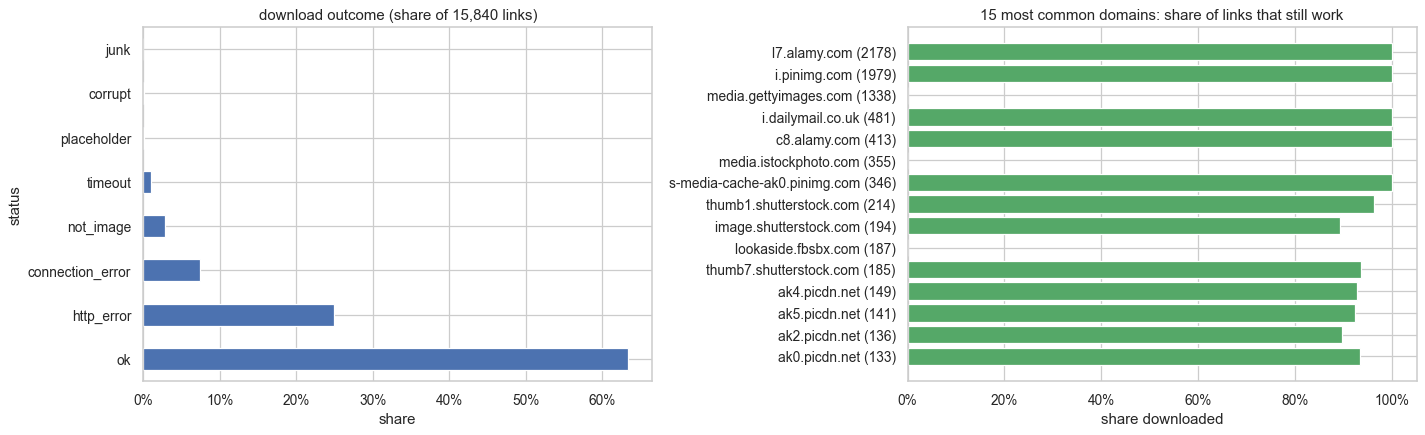

download status: {'ok': '10,038 (63.4%)', 'http_error': '3,955 (25.0%)', 'connection_error': '1,179 (7.4%)', 'not_image': '457 (2.9%)', 'timeout': '165 (1.0%)', 'placeholder': '24 (0.2%)', 'corrupt': '19 (0.1%)', 'junk': '3 (0.0%)'}
HTTP error codes: {400: 1744, 404: 1335, 403: 548, 410: 88, 503: 74, 406: 38, 429: 28, 500: 23}
distinct domains: 3,377; top 10 domains hold 48.5% of all links
duplicate captions in validation: 290; duplicate URLs: 0; empty captions: 0
caption length, downloaded vs dead links: mean 10.66 vs 9.96 words; KS D = 0.063


In [3]:
status = log.status.value_counts()
dom = (log.assign(ok=log.status == "ok").groupby("domain").agg(urls=("row", "size"), ok_share=("ok", "mean"))
       .sort_values("urls", ascending=False))
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
(status / len(log)).plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set(title="download outcome (share of 15,840 links)", xlabel="share")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
top = dom.head(15)
ax[1].barh([f"{d} ({n})" for d, n in zip(top.index[::-1], top.urls[::-1])], top.ok_share[::-1], color="#55A868")
ax[1].set(title="15 most common domains: share of links that still work", xlabel="share downloaded")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); savefig("cc_download"); plt.show()

http = log[log.status == "http_error"].http_code.dropna().astype(int).value_counts().head(8)
print("download status:", {k: f"{v:,} ({v / len(log):.1%})" for k, v in status.items()})
print("HTTP error codes:", http.to_dict())
print(f"distinct domains: {log.domain.nunique():,}; top 10 domains hold {dom.urls.head(10).sum() / len(log):.1%} of all links")

dup_caption = int(all_val.caption.duplicated().sum())
dup_url = int(all_val.url.duplicated().sum())
print(f"duplicate captions in validation: {dup_caption}; duplicate URLs: {dup_url}; empty captions: {int((all_val.caption.str.strip() == '').sum())}")

# Do dead links bias what we can analyse? Compare captions of downloaded vs dead rows.
len_ok = all_val[all_val.downloaded].caption.str.split().map(len)
len_dead = all_val[~all_val.downloaded].caption.str.split().map(len)
ks = stats.ks_2samp(len_ok, len_dead)
print(f"caption length, downloaded vs dead links: mean {len_ok.mean():.2f} vs {len_dead.mean():.2f} words; KS D = {ks.statistic:.3f}")

DL = {"rows": len(log), "status": status.to_dict(), "ok_share": float((log.status == "ok").mean()),
      "http_codes": {str(k): int(v) for k, v in http.items()}, "domains": int(log.domain.nunique()),
      "top_domains": {d: {"urls": int(r.urls), "ok_share": round(float(r.ok_share), 3)} for d, r in dom.head(10).iterrows()},
      "dup_captions": dup_caption, "dup_urls": dup_url, "ks_len_downloaded_vs_dead": float(ks.statistic),
      "len_downloaded": float(len_ok.mean()), "len_dead": float(len_dead.mean())}

## A2. Raw text statistics

CC captions are distributed **already lowercased and tokenised** (punctuation split off, e.g. *"an angler fishes river on
a snowy day ."*). Raw tokens = the caption split on spaces, exactly as distributed.

- **"train"** = the fixed 300k sample of train captions
- **"val"** = all 15,840 validation captions

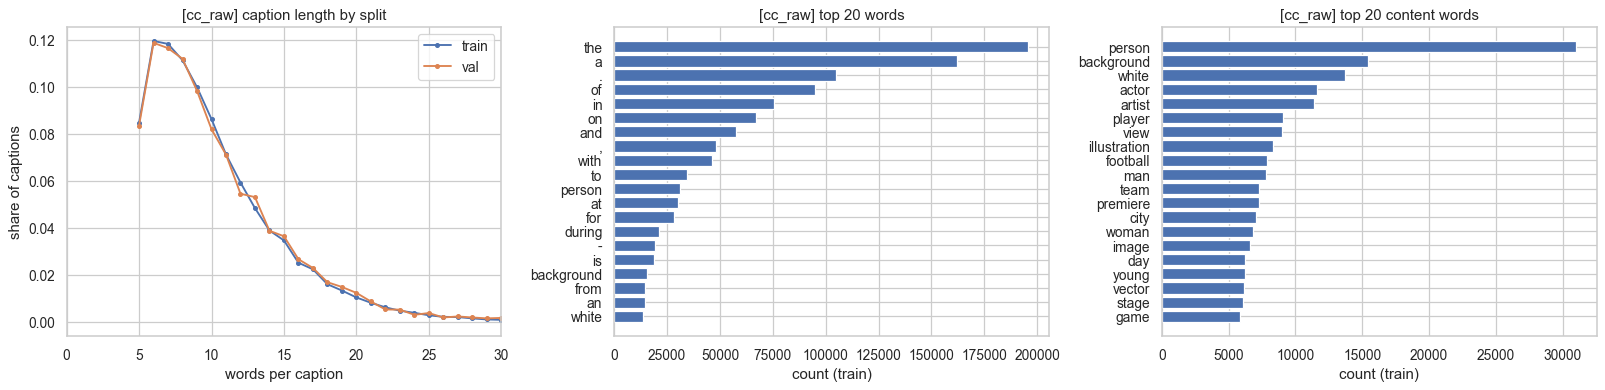

,cc_raw
captions,3.158e+05
tokens,3.255e+06
types_all_splits,2.624e+04
train_tokens,3.091e+06
train_types,2.582e+04
ttr,0.008354
root_ttr,14.69
mtld,131.3
hapax,"6,646"
hapax_pct_types,0.2574


,top bigrams,top trigrams,"collocations (PMI, freq ≥ 20)"
0,"in the (30,359)","a white background (4,434)",liga mx (16.8)
1,"on the (21,445)","on a white (4,349)",paisley bandanna (15.9)
2,"of the (21,097)",": person , (3,189)",governmental jurisdiction (15.8)
3,"on a (20,886)","image may contain (3,132)",dual carriageway (15.8)
4,"of a (18,955)","may contain : (3,132)",gon na (15.5)
5,"in a (15,703)","contain : person (3,132)",wan na (15.5)
6,"at the (13,083)","illustration of a (3,059)",astronomical observatory (15.4)
7,"with a (10,095)","a musical instrument (2,834)",ottoman turkish (15.4)
8,"during the (7,568)","playing a musical (2,833)",aurora borealis (15.3)
9,"white background (6,900)",", on stage (2,741)",prime minister (14.9)


,NOUN,VERB,ADJ
0,person (2005),is (1264),white (909)
1,background (1014),are (395),young (395)
2,actor (776),was (367),black (353)
3,artist (669),playing (295),red (305)
4,view (620),attends (294),beautiful (281)
5,player (591),be (283),old (278)
6,football (530),looking (255),new (272)
7,illustration (512),sitting (240),green (251)
8,man (498),isolated (234),musical (246)
9,team (488),contain (202),first (235)


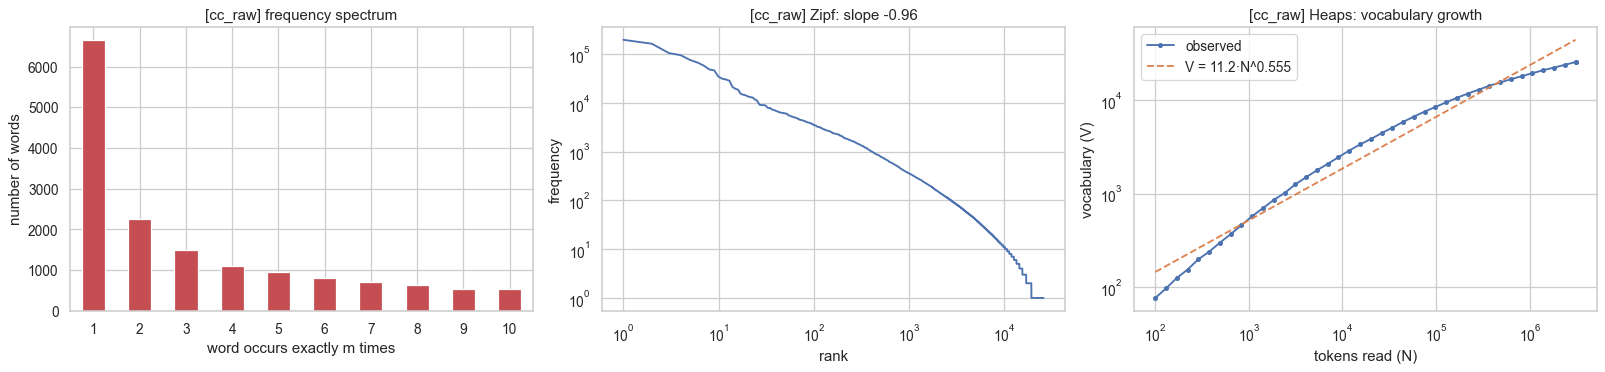

hapax: 6,646 words = 25.7% of the vocabulary, 0.22% of all tokens; dis legomena: 2,257 (8.7%)


In [4]:
raw_df = pd.concat([pd.DataFrame({"split": "train", "text": train_sample}),
                    pd.DataFrame({"split": "val", "text": all_val.caption, "row": all_val.row})], ignore_index=True)
raw_df["tokens"] = raw_df.text.str.split()
S_raw, F_raw = text_stats(raw_df, "cc_raw", splits=SPLITS)
F_raw["split"] = raw_df.split
C_raw, P_raw = char_stats(raw_df[raw_df.split == "val"].text)
S_raw.update({f"chars_{k}": v for k, v in C_raw.items()})
show_text_stats(S_raw, F_raw, "cc_raw", splits=SPLITS)
plot_rare(F_raw, S_raw, "cc_raw")

### A2.1 Check against the paper (all 3.3M train captions)

Paper Table 3: 3,318,333 train captions, 51,201 unique tokens, 10.3 tokens per caption on average (std 4.5, median 9).
We stream the full train file to check that what we downloaded matches.

In [5]:
full_counts, full_lens = Counter(), []
with open(CC / "train_captions.txt", encoding="utf-8") as f:
    for line in f:
        t = line.split()
        full_counts.update(t)
        full_lens.append(len(t))
full_lens = np.array(full_lens)
PAPER = pd.DataFrame({
    "paper (Table 3)": [3_318_333, 51_201, 10.3, 4.5, 9.0],
    "measured": [len(full_lens), len(full_counts), round(full_lens.mean(), 2), round(full_lens.std(), 2), float(np.median(full_lens))],
}, index=["train captions", "unique tokens", "mean tokens/caption", "std", "median"])
display(PAPER)
full_spec = Counter(full_counts.values())
S_raw["full_train_types"] = len(full_counts)
S_raw["full_train_hapax_pct_types"] = full_spec[1] / len(full_counts)
print(f"full train: {len(full_counts):,} types, hapax {full_spec[1]:,} ({full_spec[1] / len(full_counts):.1%})")

,paper (Table 3),measured
train captions,3318333.0,3318333.00
unique tokens,51201.0,51200.00
mean tokens/caption,10.3,10.31
std,4.5,4.67
median,9.0,9.00


full train: 51,200 types, hapax 16,543 (32.3%)


### A2.2 What makes CC captions different

* **Hypernyms:** CC replaces names with generic words (*actor, person, city, team…*). How often do these appear?
* **Punctuation tokens:** CC splits punctuation into separate tokens (`.` `,` `'s` `--`).
* **Missing determiners:** web-style captions often lack "a/an/the" (*"actor attends the premiere at festival"*).
* **Directional words:** "left/right", needed for the flip decision.

In [6]:
val_raw = raw_df[raw_df.split == "val"]
HYPERNYMS = ["person", "people", "actor", "actress", "artist", "team", "city", "country", "athlete", "player",
             "footballer", "musician", "singer", "author", "politician", "celebrity", "organisation", "business",
             "model", "film", "character", "writer", "pop artist", "rock artist", "comic book character"]
coco_train_text = [" ".join(t) for r in json.load(open(COCO / "train" / "captions_clean.json", encoding="utf-8")) for t in r["tokens"]]
coco_text = pd.Series(coco_train_text)
hyp = pd.DataFrame({
    "CC val captions": [val_raw.text.str.contains(rf"\b{h}s?\b").mean() for h in HYPERNYMS],
    "COCO train captions": [coco_text.str.contains(rf"\b{h}s?\b").mean() for h in HYPERNYMS],
}, index=HYPERNYMS).sort_values("CC val captions", ascending=False)
display(hyp.head(15).style.format("{:.2%}"))

punct_tokens = Counter(t for ts in val_raw.tokens for t in ts if not any(ch.isalnum() for ch in t) or t in ("'s", "s'"))
print("punctuation-only tokens in validation captions:", dict(punct_tokens.most_common(12)))
DETS = {"a", "an", "the"}
no_det_cc = float(np.mean([not (set(ts) & DETS) for ts in val_raw.tokens]))
no_det_coco = float(np.mean([not (set(s.split()) & DETS) for s in coco_train_text]))
print(f"captions with no a/an/the: CC {no_det_cc:.1%} vs COCO {no_det_coco:.1%}")
lr = val_raw.text.str.contains(r"\b(?:left|right)\b")
print(f"validation captions mentioning left/right: {lr.mean():.2%}")
CC_SPECIFIC = {"hypernym_share": hyp.head(10)["CC val captions"].round(4).to_dict(),
               "hypernym_share_coco": hyp.head(10)["COCO train captions"].round(4).to_dict(),
               "punct_tokens": dict(punct_tokens.most_common(10)), "no_determiner_cc": no_det_cc,
               "no_determiner_coco": no_det_coco, "left_right": float(lr.mean())}
S_raw["left_right_captions"] = float(lr.mean())

,CC val captions,COCO train captions
person,10.37%,4.13%
actor,2.92%,0.00%
artist,2.77%,0.00%
city,2.30%,1.75%
people,1.76%,6.97%
player,1.74%,2.00%
team,1.38%,0.13%
film,1.28%,0.01%
model,0.98%,0.09%
country,0.84%,0.21%


punctuation-only tokens in validation captions: {'.': 5203, ',': 2592, '-': 1029, ':': 793, '!': 546, "'s": 523, '?': 211, '#': 196, '...': 154, '--': 129, '&': 88, ';': 23}
captions with no a/an/the: CC 12.8% vs COCO 4.5%
validation captions mentioning left/right: 1.02%


## A3. Raw image statistics (downloaded validation images)

The same measurements as for COCO: decode every image, record size/mode/format/file size, and measure colour, brightness,
contrast and sharpness on a 256-px thumbnail, plus a perceptual hash for duplicates.

The CC paper kept only JPEGs with both sides > 400 px and aspect ratio ≤ 2. We check whether that still holds,
since web servers may now return different files.

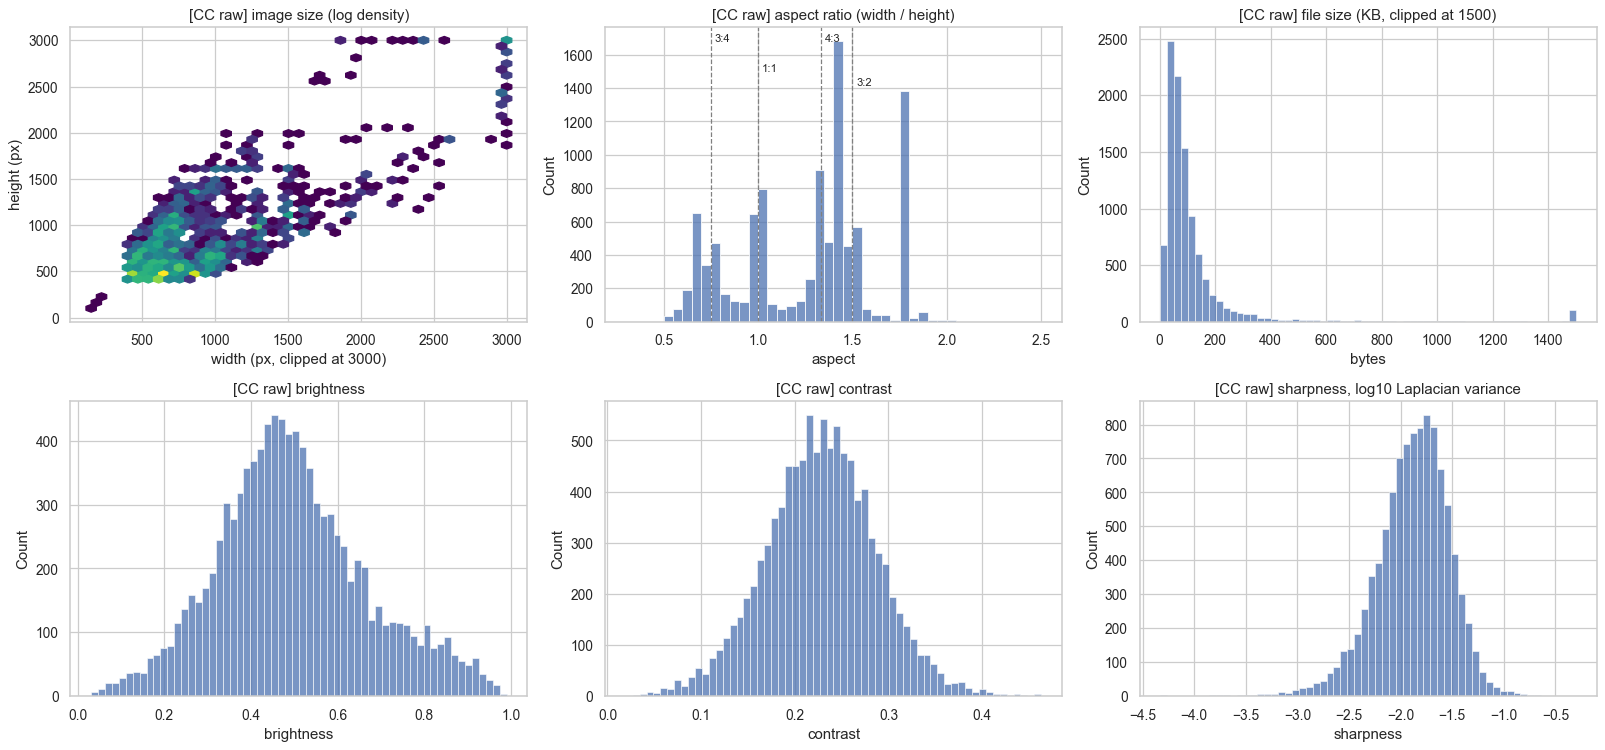

{
 "images": 10038,
 "unreadable": 0,
 "formats": {
  "JPEG": 10006,
  "WEBP": 28,
  "MPO": 4
 },
 "modes": {
  "RGB": 9971,
  "L": 64,
  "CMYK": 3
 },
 "grayscale": 64,
 "distinct_sizes": 3340,
 "median_width": 640.0,
 "median_height": 494.0,
 "min_side_over_400": 0.9829647340107591,
 "aspect_le_2": 1.0,
 "orientation": {
  "landscape": 0.639,
  "portrait": 0.218,
  "square-ish": 0.144
 },
 "median_kb": 73.3798828125,
 "pixel_mean": [
  0.5238,
  0.499,
  0.4692
 ],
 "pixel_std": [
  0.3088,
  0.3024,
  0.3145
 ],
 "colourfulness_mean": 0.05474843050822406,
 "brightness_mean": 0.49622685830286406,
 "very_dark": 175,
 "very_bright": 375,
 "low_contrast": 87
}


In [7]:
im_df, PIX_MEAN, PIX_STD = image_pass((VAL / "images" / r.image, {"split": "val", "row": r.row, "image": r.image})
                                      for r in got.itertuples())
ok = im_df[im_df.ok]
side_min, side_max = ok[["width", "height"]].min(axis=1), ok[["width", "height"]].max(axis=1)

fig, ax = plt.subplots(2, 3, figsize=(18, 8.5))
ax[0, 0].hexbin(ok.width.clip(upper=3000), ok.height.clip(upper=3000), gridsize=40, bins="log", cmap="viridis")
ax[0, 0].set(xlabel="width (px, clipped at 3000)", ylabel="height (px)", title="[CC raw] image size (log density)")
sns.histplot(ok.aspect.clip(0.3, 2.5), bins=np.arange(0.3, 2.55, 0.05), ax=ax[0, 1])
for v, lbl, y in [(3 / 4, "3:4", 0.95), (1, "1:1", 0.85), (4 / 3, "4:3", 0.95), (3 / 2, "3:2", 0.8)]:
    ax[0, 1].axvline(v, ls="--", c="gray", lw=1)
    ax[0, 1].text(v + 0.02, ax[0, 1].get_ylim()[1] * y, lbl, fontsize=9)
ax[0, 1].set(title="[CC raw] aspect ratio (width / height)")
sns.histplot((ok.bytes / 1024).clip(upper=1500), bins=60, ax=ax[0, 2]); ax[0, 2].set(title="[CC raw] file size (KB, clipped at 1500)")
sns.histplot(ok.brightness, bins=60, ax=ax[1, 0]); ax[1, 0].set(title="[CC raw] brightness")
sns.histplot(ok.contrast, bins=60, ax=ax[1, 1]); ax[1, 1].set(title="[CC raw] contrast")
sns.histplot(np.log10(ok.sharpness), bins=60, ax=ax[1, 2]); ax[1, 2].set(title="[CC raw] sharpness, log10 Laplacian variance")
plt.tight_layout(); savefig("cc_raw_images"); plt.show()

IMG_RAW = {
    "images": int(len(im_df)), "unreadable": int((~im_df.ok).sum()),
    "formats": ok["format"].value_counts().to_dict(), "modes": ok["mode"].value_counts().to_dict(),
    "grayscale": int((ok["mode"] == "L").sum()), "distinct_sizes": int((ok.width.astype(str) + "x" + ok.height.astype(str)).nunique()),
    "median_width": float(ok.width.median()), "median_height": float(ok.height.median()),
    "min_side_over_400": float((side_min > 400).mean()), "aspect_le_2": float((side_max / side_min <= 2).mean()),
    "orientation": ok.orientation.value_counts(normalize=True).round(3).to_dict(),
    "median_kb": float(ok.bytes.median() / 1024),
    "pixel_mean": PIX_MEAN.round(4).tolist(), "pixel_std": PIX_STD.round(4).tolist(),
    "colourfulness_mean": float(ok.colourfulness.mean()), "brightness_mean": float(ok.brightness.mean()),
    "very_dark": int((ok.brightness < 0.15).sum()), "very_bright": int((ok.brightness > 0.85).sum()),
    "low_contrast": int((ok.contrast < 0.08).sum()),
}
print(json.dumps(IMG_RAW, indent=1))

### A3.1 Examples, extremes and duplicates

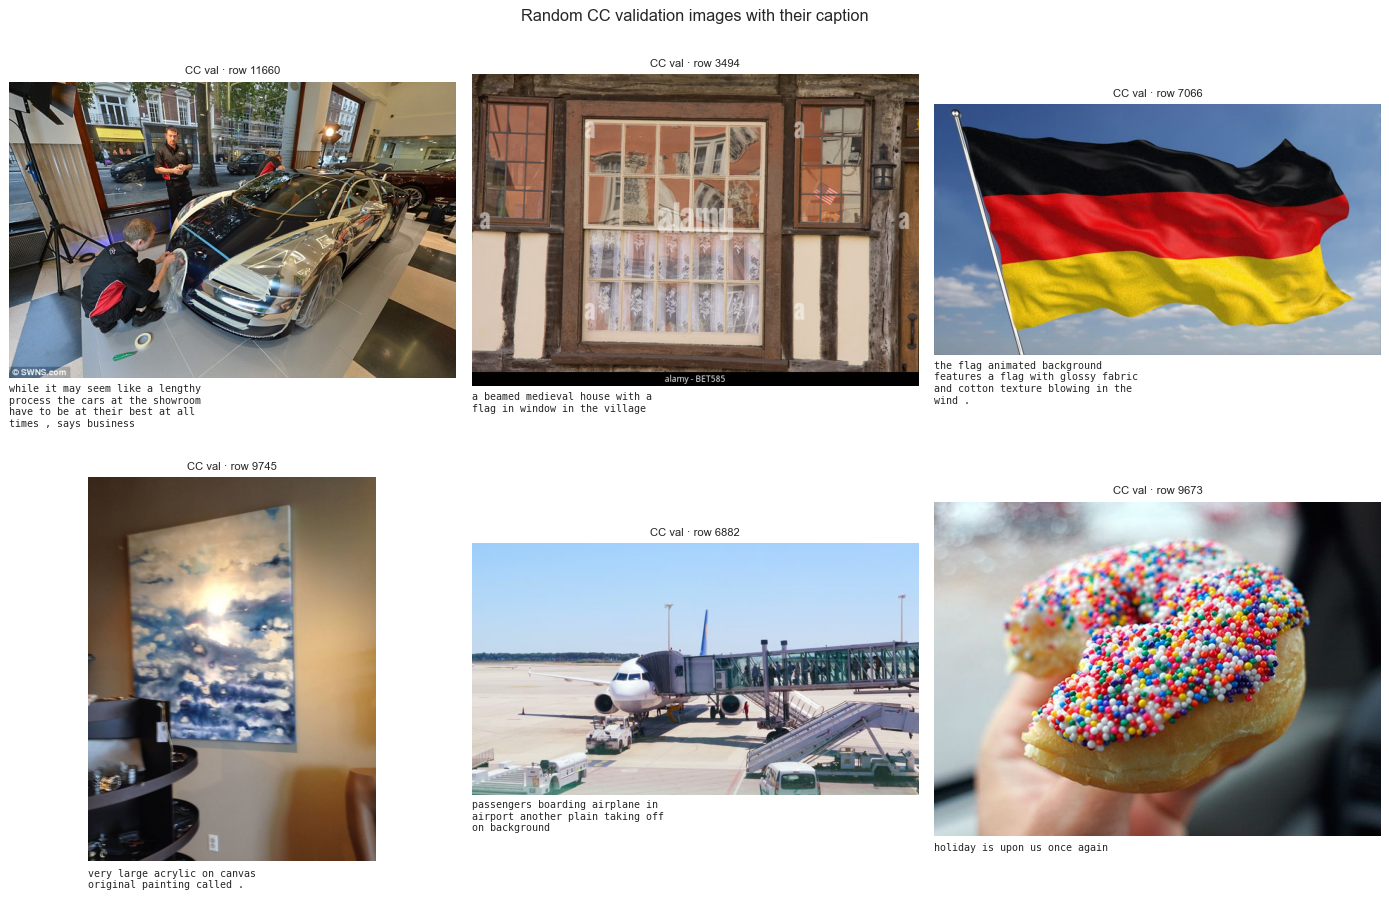

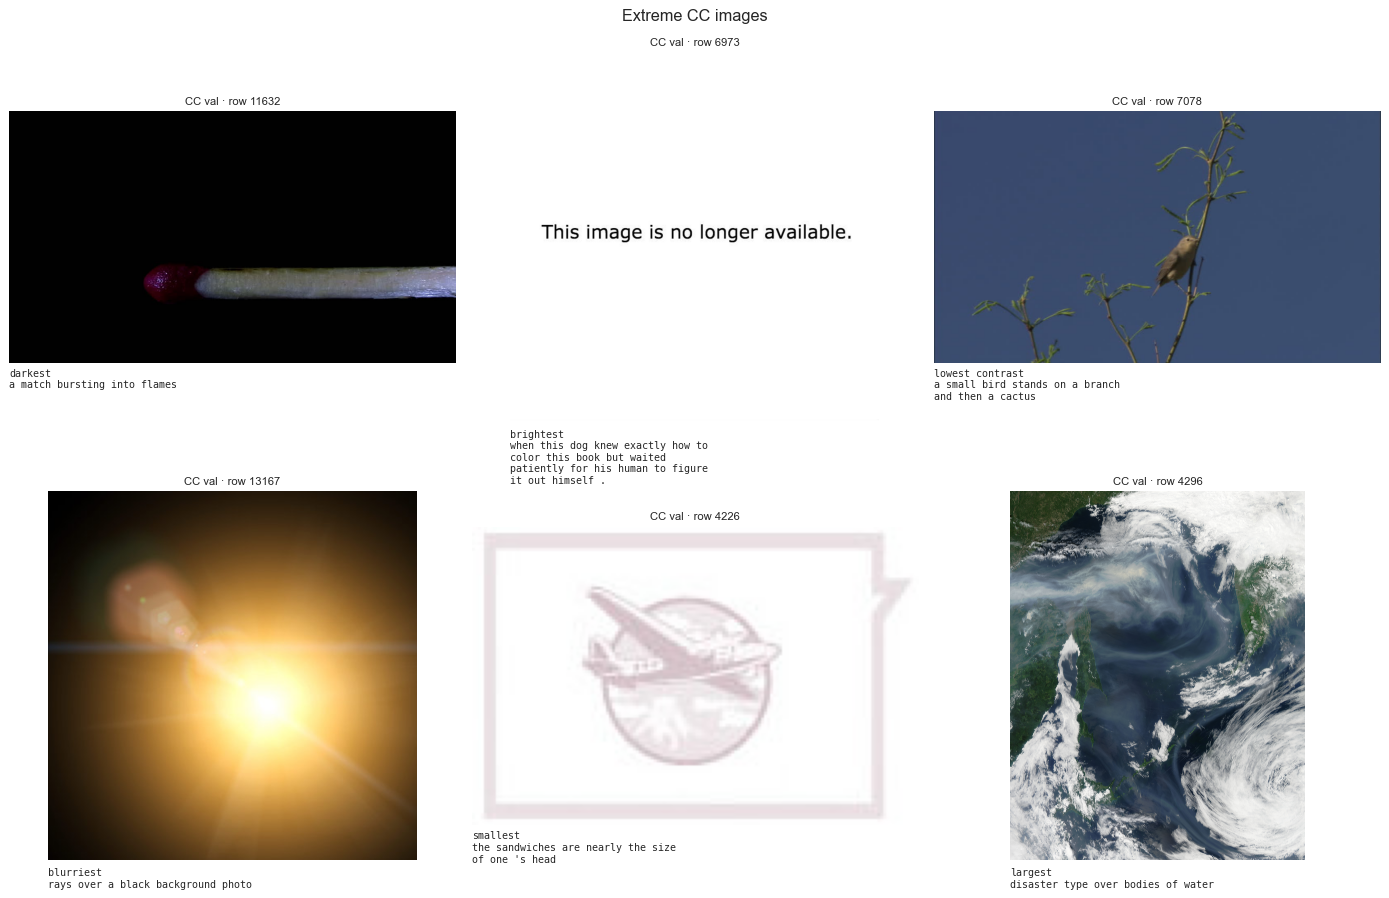

In [8]:
def cc_item(row, text, label=""):
    return (VAL / "images" / img_of[row], f"CC val · row {row}", (label + "\n" if label else "") + textwrap.fill(text, 34))

cap_of = dict(zip(all_val.row, all_val.caption))
sample_rows = got.sample(6, random_state=SEED).row
show_images([cc_item(r, cap_of[r]) for r in sample_rows], 3, "cc_samples_random", "Random CC validation images with their caption", text_lines=4)

picks = [("darkest", ok.nsmallest(1, "brightness")), ("brightest", ok.nlargest(1, "brightness")),
         ("lowest contrast", ok.nsmallest(1, "contrast")), ("blurriest", ok.nsmallest(1, "sharpness")),
         ("smallest", ok.loc[side_min.nsmallest(1).index]), ("largest", ok.loc[side_max.nlargest(1).index])]
show_images([cc_item(r.row, cap_of[r.row], lbl) for lbl, d in picks for r in d.itertuples()], 3, "cc_image_extremes",
            "Extreme CC images", text_lines=4)

CC validation: hash candidates 334 -> confirmed duplicate pairs 3


,a,b,split_a,split_b,hamming,aspect_diff,pixel_corr,confirmed,cross_split
225,659,1044,val,val,0,0.0,1.00000,True,False
70,3382,7804,val,val,0,0.0,1.00000,True,False
288,5087,7566,val,val,0,0.0,0.99858,True,False


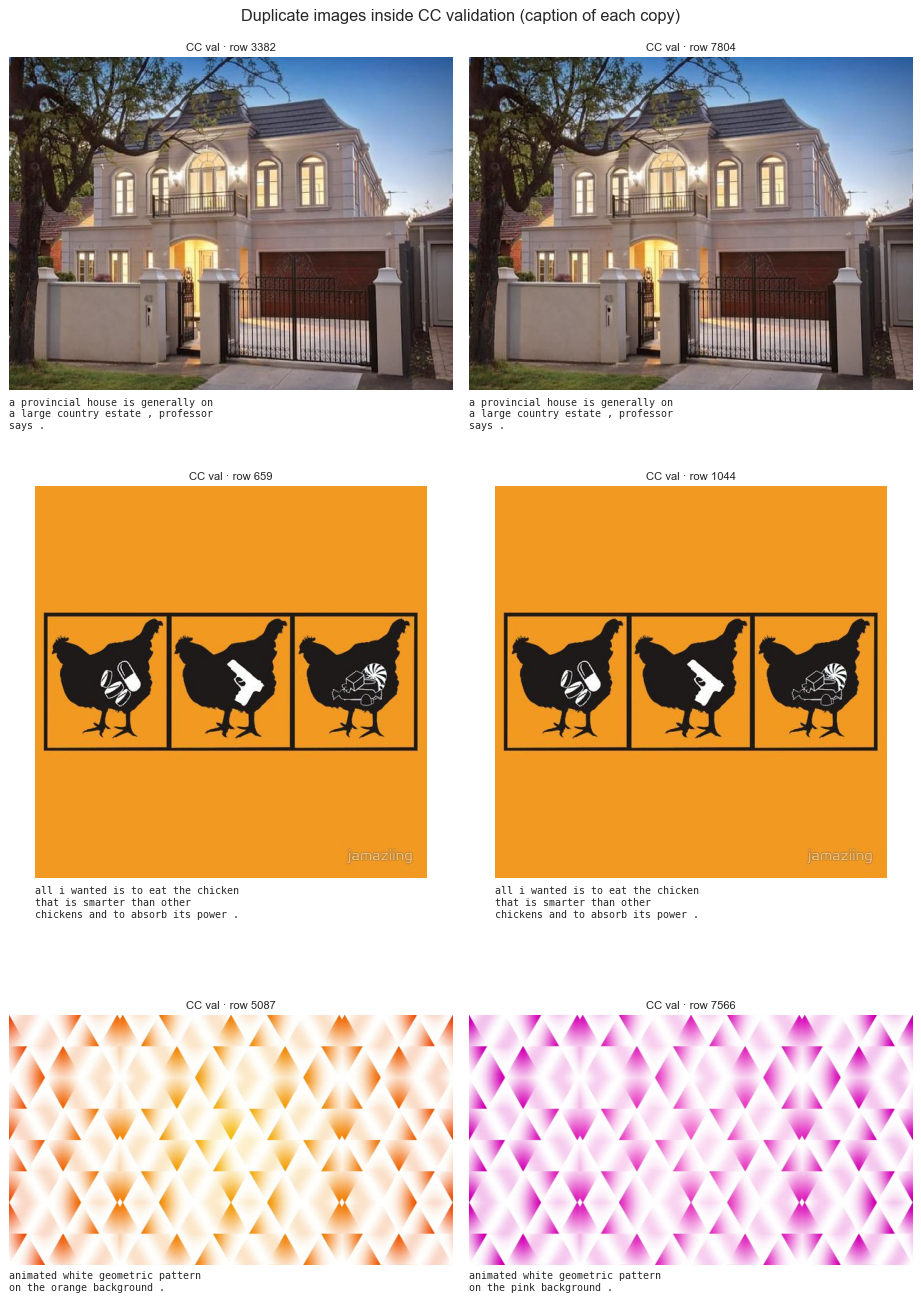

COCO <-> CC: candidate pairs across datasets 495 -> confirmed duplicates 0


,a,b,split_a,split_b,hamming,aspect_diff,pixel_corr,confirmed,cross_split


In [9]:
# duplicates inside CC validation
dup = find_duplicates(ok, "row", "split", lambda r: VAL / "images" / img_of[r])
conf = dup[dup.confirmed]
print(f"CC validation: hash candidates {len(dup)} -> confirmed duplicate pairs {len(conf)}")
display(conf.sort_values("pixel_corr", ascending=False).head(10))
conf.to_csv(ANALYSIS / "duplicate_images.csv", index=False)
if len(conf):
    items = [cc_item(r, cap_of[r]) for p in conf.head(3).itertuples() for r in (p.a, p.b)]
    show_images(items, 2, "cc_duplicates", "Duplicate images inside CC validation (caption of each copy)", text_lines=4)

# duplicates between CC and COCO (would leak if both datasets are used together)
coco_info = pd.read_csv(COCO / "analysis" / "image_info.csv")
coco_ok = coco_info[coco_info.ok].copy()
both = pd.concat([
    coco_ok.assign(uid="coco:" + coco_ok.cocoid.astype(str), dataset="coco",
                   path=[COCO / s / "images" / i for s, i in zip(coco_ok.split, coco_ok.image)]),
    ok.assign(uid="cc:" + ok.row.astype(str), dataset="cc", path=[VAL / "images" / i for i in ok.image]),
], ignore_index=True)
path_of = dict(zip(both.uid, both.path))
xdup = find_duplicates(both, "uid", "dataset", path_of.get)
xconf = xdup[xdup.confirmed & xdup.cross_split]
print(f"COCO <-> CC: candidate pairs across datasets {int(xdup.cross_split.sum())} -> confirmed duplicates {len(xconf)}")
display(xconf.head(10))
xconf.to_csv(ANALYSIS / "duplicates_with_coco.csv", index=False)
IMG_RAW.update(duplicate_pairs=int(len(conf)), hash_candidates=int(len(dup)),
               coco_cross_candidates=int(xdup.cross_split.sum()), coco_cross_duplicates=int(len(xconf)))

---
# Part B: Preprocessing (CC's own pipeline)

| Step | What | Why |
|---|---|---|
| 1 | Unicode NFKC, collapse whitespace | identical-looking characters become identical bytes |
| 2 | Lowercase | CC is distributed lowercased; this step verifies it |
| 3 | Join possessives (`child 's` → `childs`), drop other apostrophes | CC splits `'s` into its own token; Karpathy/COCO convention joins it |
| 4 | Punctuation tokens and hyphens → removed / space | `.` `,` `--` carry no content |
| 5 | **No spelling correction** | CC's pipeline already rejected captions with unknown tokens (measured in A2: very few likely typos) |
| 6 | Drop captions that become empty | nothing left to learn from |
| Vocab | built from **all 3.3M train captions** (streamed), words with count ≥ **4**, + `<pad> <start> <end> <unk>` | the CC paper's setting (min count 4) |
| Max length | **15 tokens** | the CC paper's setting; compared with the measured 99th percentile below |

The image pipeline is the same as COCO: RGB → resize shorter side 224 (bicubic) → centre-crop 224 → normalise.
Originals are kept.

In [10]:
def c1(s): return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", s)).strip()
def c2(s): return s.lower()
def c3(s): return re.sub(r"['’`]", "", re.sub(r"\s+['’]\s*s\b", "s", s))
def c4(s): return re.sub(r"[^a-z0-9]+", " ", s).strip()

def clean(s):
    return c4(c3(c2(c1(s))))

steps = [("1 NFKC + whitespace", c1), ("2 lowercase", c2), ("3 join possessives / drop apostrophes", c3),
         ("4 punctuation -> removed", c4)]
cur = raw_df.text.copy()
step_log = []
for name, fn in steps:
    new = cur.map(fn)
    step_log.append({"step": name, "captions changed": int((new != cur).sum()), "share": (new != cur).mean()})
    cur = new
raw_df["clean"] = cur
empty = raw_df.clean.str.strip() == ""
step_log.append({"step": "5 spelling correction", "captions changed": 0, "share": 0.0})
step_log.append({"step": "6 drop empty captions", "captions changed": int(empty.sum()), "share": empty.mean()})
STEP_LOG = pd.DataFrame(step_log)
print(f"likely typo words in the raw 300k train sample: {S_raw['likely_typo_types']:,} "
      f"({S_raw['likely_typo_types'] / S_raw['train_types']:.2%} of its vocabulary) -> no spelling correction needed")
STEP_LOG.style.format({"share": "{:.2%}"})

likely typo words in the raw 300k train sample: 1,199 (4.64% of its vocabulary) -> no spelling correction needed


,step,captions changed,share
0,1 NFKC + whitespace,0,0.00%
1,2 lowercase,4,0.00%
2,3 join possessives / drop apostrophes,11246,3.56%
3,4 punctuation -> removed,161772,51.22%
4,5 spelling correction,0,0.00%
5,6 drop empty captions,0,0.00%


In [11]:
# vocabulary from ALL train captions (streamed, cleaned the same way)
vocab_counts, clean_lens = Counter(), []
with open(CC / "train_captions.txt", encoding="utf-8") as f:
    for line in f:
        t = clean(line).split()
        vocab_counts.update(t)
        clean_lens.append(len(t))
clean_lens = np.array(clean_lens)
MIN_FREQ, MAX_LEN = 4, 15
SPECIALS = ["<pad>", "<start>", "<end>", "<unk>"]
itos = SPECIALS + sorted(w for w, c in vocab_counts.items() if c >= MIN_FREQ)
cov = sum(c for w, c in vocab_counts.items() if c >= MIN_FREQ) / sum(vocab_counts.values())
p99 = float(np.percentile(clean_lens, 99))
trunc = float((clean_lens > MAX_LEN).mean())
print(f"full train after cleaning: {len(vocab_counts):,} distinct words; vocabulary (count >= {MIN_FREQ}): {len(itos):,} tokens incl. specials, "
      f"covering {cov:.2%} of train tokens")
print(f"max length {MAX_LEN} tokens (paper) vs measured 99th percentile {p99:.0f}: truncates {trunc:.2%} of train captions")

full train after cleaning: 48,482 distinct words; vocabulary (count >= 4): 26,990 tokens incl. specials, covering 99.90% of train tokens
max length 15 tokens (paper) vs measured 99th percentile 24: truncates 9.20% of train captions


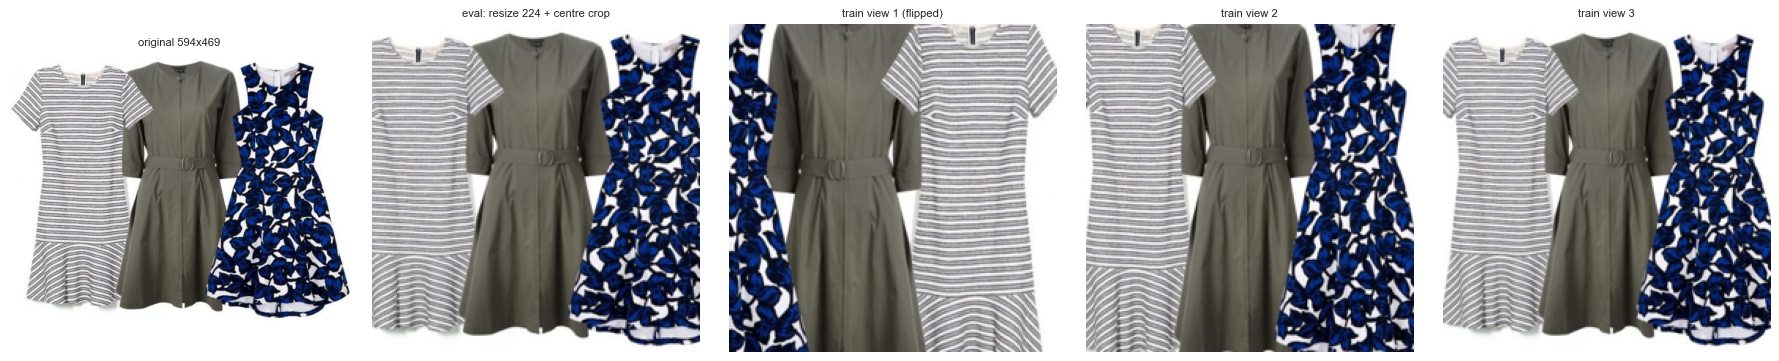

no-flip images (caption mentions left/right): 162


In [12]:
NO_FLIP = sorted(int(r) for r in all_val[all_val.caption.str.contains(r"\b(?:left|right)\b")].row)
demo = got.sample(1, random_state=3).iloc[0]
with Image.open(VAL / "images" / demo.image) as im:
    orig = im.convert("RGB")
r_demo = random.Random(1)
views = [("original " + "x".join(map(str, orig.size)), orig), ("eval: resize 224 + centre crop", center_crop(resize_shorter(orig, SIZE), SIZE))]
for i in range(3):
    crop = random_resized_crop(orig, r_demo)
    flip = int(demo.row) not in NO_FLIP and r_demo.random() < 0.5
    views.append((f"train view {i + 1}{' (flipped)' if flip else ''}", crop.transpose(Image.FLIP_LEFT_RIGHT) if flip else crop))
fig, ax = plt.subplots(1, len(views), figsize=(4 * len(views), 4))
for a, (t, v) in zip(ax, views):
    a.imshow(v); a.set_title(t, fontsize=9); a.axis("off")
plt.tight_layout(); savefig("cc_image_pipeline", dpi=80); plt.show()
print(f"no-flip images (caption mentions left/right): {len(NO_FLIP)}")

In [13]:
val_clean = raw_df[(raw_df.split == "val") & ~empty].copy()
clean_of = dict(zip(val_clean.row.astype(int), val_clean.clean))
json.dump([{"image": r.image, "row": int(r.row), "caption": clean_of[r.row], "tokens": clean_of[r.row].split()}
           for r in got.itertuples() if r.row in clean_of], open(VAL / "captions_clean.json", "w", encoding="utf-8"))
json.dump([{"row": int(r), "caption": c} for r, c in clean_of.items()], open(VAL / "all_captions_clean.json", "w", encoding="utf-8"))
json.dump({"itos": itos, "min_freq": MIN_FREQ, "max_len": MAX_LEN, "specials": SPECIALS, "built_from": "all 3,318,333 train captions"},
          open(CC / "vocab.json", "w"), indent=1)
json.dump({
    "text": {"steps": [s for s, _ in steps] + ["5 no spelling correction", "6 drop empty captions"],
             "keep_stopwords": True, "min_freq": MIN_FREQ, "max_len": MAX_LEN, "specials": SPECIALS},
    "image": {"convert": "RGB", "size": SIZE, "eval": "resize shorter side (bicubic) + centre crop",
              "train": "random resized crop scale (0.5, 1.0) ratio (3/4, 4/3)",
              "horizontal_flip": "p=0.5, except rows in no_flip_rows", "no_flip_rows": NO_FLIP,
              "normalise": {"clip": {"mean": CLIP_MEAN.tolist(), "std": CLIP_STD.tolist()},
                            "imagenet": {"mean": IMAGENET_MEAN.tolist(), "std": IMAGENET_STD.tolist()},
                            "measured_on_this_data": {"mean": IMG_RAW["pixel_mean"], "std": IMG_RAW["pixel_std"]}}},
}, open(CC / "preprocess_config.json", "w"), indent=1)
im_df.drop(columns=[c for c in ["error"] if c in im_df]).to_csv(ANALYSIS / "image_info.csv", index=False)
print("saved: val/captions_clean.json, val/all_captions_clean.json, vocab.json, preprocess_config.json, analysis/")

saved: val/captions_clean.json, val/all_captions_clean.json, vocab.json, preprocess_config.json, analysis/


---
# Part C: Clean EDA (same statistics after preprocessing)

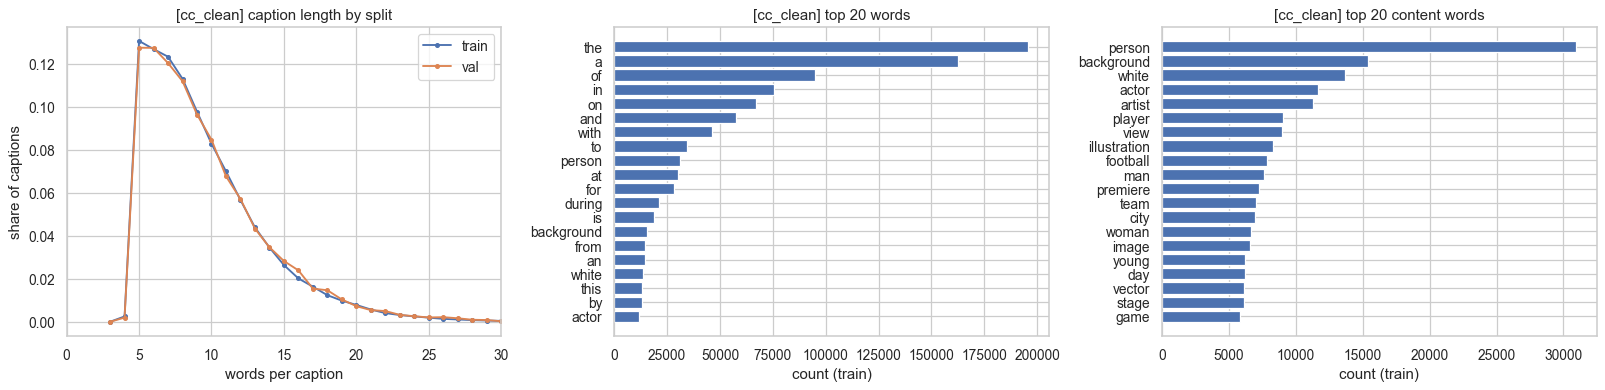

,cc_clean
captions,3.158e+05
tokens,3.027e+06
types_all_splits,2.578e+04
train_tokens,2.874e+06
train_types,2.536e+04
ttr,0.008825
root_ttr,14.96
mtld,153.9
hapax,"6,287"
hapax_pct_types,0.2479


,top bigrams,top trigrams,"collocations (PMI, freq ≥ 20)"
0,"in the (30,363)","a white background (4,434)",fa ade (17.1)
1,"on the (21,461)","on a white (4,349)",liga mx (16.7)
2,"of the (21,109)","image may contain (3,132)",2015 2016 (16.7)
3,"on a (20,915)","may contain person (3,132)",mercedes benz (16.3)
4,"of a (18,986)","illustration of a (3,063)",paisley bandanna (15.8)
5,"in a (15,740)","a musical instrument (2,834)",governmental jurisdiction (15.7)
6,"at the (13,085)","playing a musical (2,833)",dual carriageway (15.7)
7,"with a (10,115)","against sports team (2,093)",gon na (15.3)
8,"during the (7,568)","person on stage (2,071)",wan na (15.3)
9,"white background (6,900)","contain person on (2,054)",astronomical observatory (15.3)


,NOUN,VERB,ADJ
0,person (1999),is (1264),white (909)
1,background (1012),are (395),young (395)
2,actor (776),was (367),black (353)
3,artist (653),attends (294),red (304)
4,view (621),playing (293),beautiful (282)
5,player (590),be (283),old (278)
6,football (529),looking (255),new (272)
7,illustration (512),sitting (241),green (251)
8,man (487),isolated (238),musical (246)
9,team (469),contain (202),first (226)


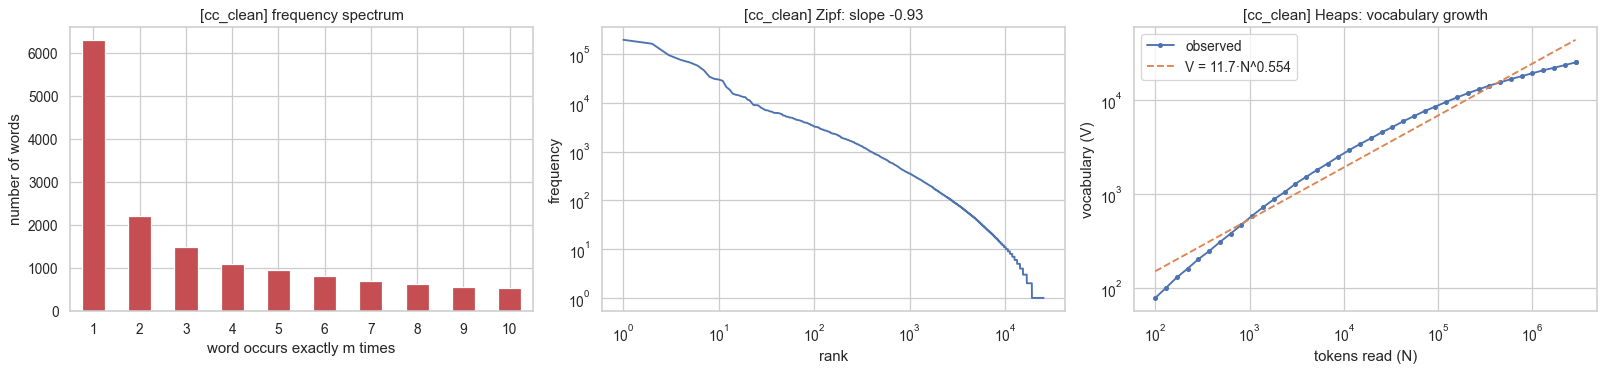

hapax: 6,287 words = 24.8% of the vocabulary, 0.22% of all tokens; dis legomena: 2,215 (8.7%)


In [14]:
clean_df = raw_df[~empty].copy()
clean_df["text"] = clean_df.clean
clean_df["tokens"] = clean_df.clean.str.split()
S_clean, F_clean = text_stats(clean_df, "cc_clean", splits=SPLITS)
F_clean["split"] = clean_df.split
C_clean, P_clean = char_stats(clean_df[clean_df.split == "val"].text)
S_clean.update({f"chars_{k}": v for k, v in C_clean.items()})
S_clean["full_train_types"] = len(vocab_counts)
S_clean["full_train_hapax_pct_types"] = Counter(vocab_counts.values())[1] / len(vocab_counts)
S_clean["left_right_captions"] = float(clean_df[clean_df.split == "val"].clean.str.contains(r"\b(?:left|right)\b").mean())
show_text_stats(S_clean, F_clean, "cc_clean", splits=SPLITS)
plot_rare(F_clean, S_clean, "cc_clean")

In [15]:
sample_imgs = got.sample(min(1000, len(got)), random_state=SEED)
shapes, t_sum, t_sq, t_n, raw_hist, new_hist = Counter(), np.zeros(3), np.zeros(3), 0, [], []
for r in sample_imgs.itertuples():
    with Image.open(VAL / "images" / r.image) as im:
        raw_mode = im.mode
        x = eval_transform(im)
        if len(raw_hist) < 200:
            raw_hist.append(np.asarray(im.convert("RGB").resize((224, 224)), dtype=np.float32).reshape(-1, 3)[::50] / 255)
    shapes[(x.shape, raw_mode)] += 1
    px = x.reshape(-1, 3)
    t_sum += px.sum(0); t_sq += (px ** 2).sum(0); t_n += len(px)
    if len(new_hist) < 200:
        new_hist.append(px[::50])
T_MEAN = t_sum / t_n
T_STD = np.sqrt(t_sq / t_n - T_MEAN ** 2)
IMG_CLEAN = {"output_shapes": {f"{k[0]} from mode {k[1]}": v for k, v in shapes.items()},
             "all_224x224x3": all(k[0] == (224, 224, 3) for k in shapes),
             "pixel_mean_after_norm": T_MEAN.round(4).tolist(), "pixel_std_after_norm": T_STD.round(4).tolist(), "distinct_sizes": 1}
print(json.dumps(IMG_CLEAN, indent=1))

{
 "output_shapes": {
  "(224, 224, 3) from mode RGB": 996,
  "(224, 224, 3) from mode L": 4
 },
 "all_224x224x3": true,
 "pixel_mean_after_norm": [
  0.1559,
  0.1597,
  0.2265
 ],
 "pixel_std_after_norm": [
  1.1357,
  1.1436,
  1.127
 ],
 "distinct_sizes": 1
}


---
# Part D: Before vs after comparison

In [16]:
ROWS = [
    ("Captions (train sample + val)", "captions"), ("Tokens", "tokens"), ("Distinct words in train sample (types)", "train_types"),
    ("Distinct words in ALL train captions", "full_train_types"), ("Hapax share, ALL train", "full_train_hapax_pct_types"),
    ("Type–token ratio", "ttr"), ("Root TTR", "root_ttr"), ("MTLD", "mtld"),
    ("Hapax legomena (train sample)", "hapax"), ("Hapax share of vocabulary", "hapax_pct_types"), ("Dis legomena", "dis_legomena"),
    ("Lemmas", "train_lemmas"), ("Types per lemma", "types_per_lemma"), ("Zipf slope", "zipf_slope"),
    ("Heaps β", "heaps_beta"), ("Heaps K", "heaps_K"),
    ("Mean caption length (tokens)", "len_mean"), ("99th percentile length", "len_p99"), ("Max length", "len_max"),
    ("Mean word length (chars)", "word_len_mean"), ("Stopword share", "stopword_share"),
    ("Types not dictionary words as written", "types_not_dictionary_as_written"), ("Likely typo words", "likely_typo_types"),
    ("Vocabulary at min-freq 5 (train sample)", "vocab_min5"), ("Train coverage at min-freq 5", "train_coverage_min5"),
    ("Val OOV tokens (min-freq 1)", "val_oov_tokens_min1"), ("Val OOV tokens (min-freq 5)", "val_oov_tokens_min5"),
    ("Val captions with ≥1 OOV (min-freq 5)", "val_oov_captions_min5"), ("Vocabulary overlap train/val (Jaccard)", "jaccard_train_val"),
    ("Val captions with punctuation", "chars_has_punctuation"), ("Distinct characters (val)", "chars_distinct_characters"),
    ("POS: nouns", "pos_noun"), ("POS: verbs", "pos_verb"), ("POS: adjectives", "pos_adj"),
]
cmp = pd.DataFrame([{"metric": n, "raw": S_raw.get(k), "clean": S_clean.get(k)} for n, k in ROWS])
cmp["change"] = [(c - r) / r if isinstance(r, (int, float)) and r not in (0, None) else np.nan for r, c in zip(cmp.raw, cmp.clean)]
img_rows = pd.DataFrame([
    {"metric": "Image: distinct sizes", "raw": IMG_RAW["distinct_sizes"], "clean": IMG_CLEAN["distinct_sizes"]},
    {"metric": "Image: grayscale images", "raw": IMG_RAW["grayscale"], "clean": 0},
    *[{"metric": f"Image: channel {c} mean", "raw": IMG_RAW["pixel_mean"][i], "clean": IMG_CLEAN["pixel_mean_after_norm"][i]} for i, c in enumerate("RGB")],
    *[{"metric": f"Image: channel {c} std", "raw": IMG_RAW["pixel_std"][i], "clean": IMG_CLEAN["pixel_std_after_norm"][i]} for i, c in enumerate("RGB")],
])
COMPARISON = pd.concat([cmp, img_rows], ignore_index=True)
COMPARISON.to_csv(ROOT / "eda" / "cc_comparison.csv", index=False)
COMPARISON.style.format({"raw": "{:,.4g}", "clean": "{:,.4g}", "change": "{:+.1%}"}, na_rep="")

,metric,raw,clean,change
0,Captions (train sample + val),3.158e+05,3.158e+05,+0.0%
1,Tokens,3.255e+06,3.027e+06,-7.0%
2,Distinct words in train sample (types),2.582e+04,2.536e+04,-1.8%
3,Distinct words in ALL train captions,5.12e+04,4.848e+04,-5.3%
4,"Hapax share, ALL train",0.3231,0.3005,-7.0%
5,Type–token ratio,0.008354,0.008825,+5.6%
6,Root TTR,14.69,14.96,+1.9%
7,MTLD,131.3,153.9,+17.2%
8,Hapax legomena (train sample),"6,646","6,287",-5.4%
9,Hapax share of vocabulary,0.2574,0.2479,-3.7%


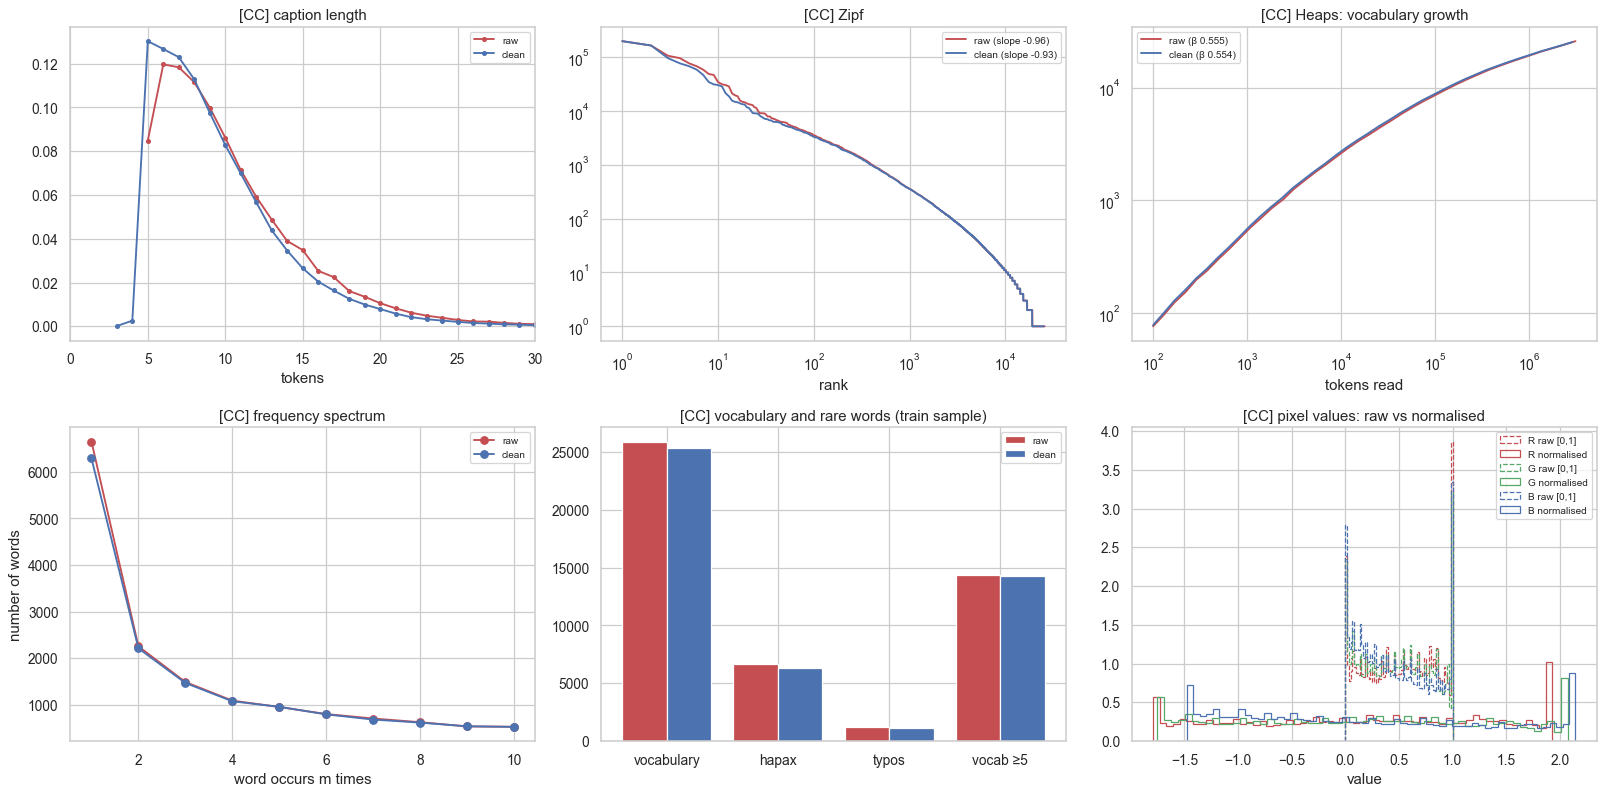

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
for F, S, lbl, c in [(F_raw, S_raw, "raw", "#C44E52"), (F_clean, S_clean, "clean", "#4C72B0")]:
    vals = F["n_words"].value_counts(normalize=True).sort_index()
    ax[0, 0].plot(vals.index, vals.values, "o-", ms=3, c=c, label=lbl)
    r, f = F["zipf"]; ax[0, 1].loglog(r, f, c=c, label=f"{lbl} (slope {S['zipf_slope']:.2f})")
    x, y = F["heaps"]; ax[0, 2].loglog(x, y, c=c, label=f"{lbl} (β {S['heaps_beta']:.3f})")
    ax[1, 0].plot(F["spectrum"].index, F["spectrum"].values, "o-", c=c, label=lbl)
ax[0, 0].set(title="[CC] caption length", xlabel="tokens", xlim=(0, 30))
ax[0, 1].set(title="[CC] Zipf", xlabel="rank")
ax[0, 2].set(title="[CC] Heaps: vocabulary growth", xlabel="tokens read")
ax[1, 0].set(title="[CC] frequency spectrum", xlabel="word occurs m times", ylabel="number of words")
keys = [("train_types", "vocabulary"), ("hapax", "hapax"), ("likely_typo_types", "typos"), ("vocab_min5", "vocab ≥5")]
xx = np.arange(len(keys))
ax[1, 1].bar(xx - 0.2, [S_raw[k] for k, _ in keys], 0.4, color="#C44E52", label="raw")
ax[1, 1].bar(xx + 0.2, [S_clean[k] for k, _ in keys], 0.4, color="#4C72B0", label="clean")
ax[1, 1].set_xticks(xx, [n for _, n in keys]); ax[1, 1].set(title="[CC] vocabulary and rare words (train sample)")
raw_px, new_px = np.concatenate(raw_hist), np.concatenate(new_hist)
for i, c in enumerate(["#C44E52", "#55A868", "#4C72B0"]):
    ax[1, 2].hist(raw_px[:, i], bins=60, histtype="step", color=c, ls="--", density=True, label=f"{'RGB'[i]} raw [0,1]")
    ax[1, 2].hist(new_px[:, i], bins=60, histtype="step", color=c, density=True, label=f"{'RGB'[i]} normalised")
ax[1, 2].set(title="[CC] pixel values: raw vs normalised", xlabel="value")
for a in ax.ravel():
    a.legend(fontsize=8)
plt.tight_layout(); savefig("cc_cmp_before_after"); plt.show()

---
# Part E: COCO vs Conceptual Captions

Both datasets are compared **after cleaning**:
- **COCO:** the 30k train / val split and its cleaned captions
- **CC:** the train-caption sample and the validation set

Size-dependent numbers (types, TTR) are not comparable across corpora of different sizes. MTLD, hapax share, length and
POS mix are. The most important number is the **cross-vocabulary OOV**: how many words of one dataset the other dataset's
vocabulary does not know, i.e. the domain gap a model trained on one would face on the other.

In [18]:
coco_sum = json.load(open(ROOT / "eda" / "summary_clean.json"))
coco_raw_sum = json.load(open(ROOT / "eda" / "summary_raw.json"))
coco_vocab = set(json.load(open(COCO / "vocab.json"))["itos"])
cc_vocab = set(itos)
cc_val_tokens = clean_df[clean_df.split == "val"].tokens.tolist()

def oov(token_lists, vocab):
    toks = [t for ts in token_lists for t in ts]
    return float(np.mean([t not in vocab for t in toks])), float(np.mean([any(t not in vocab for t in ts) for ts in token_lists]))

coco_val_lists = [r_t for r in json.load(open(COCO / "val" / "captions_clean.json", encoding="utf-8")) for r_t in r["tokens"]]
cc_in_coco_tok, cc_in_coco_cap = oov(cc_val_tokens, coco_vocab)
coco_in_cc_tok, coco_in_cc_cap = oov(coco_val_lists, cc_vocab)
cc_in_cc_tok, cc_in_cc_cap = oov(cc_val_tokens, cc_vocab)
coco_in_coco_tok, coco_in_coco_cap = oov(coco_val_lists, coco_vocab)

ct = coco_sum["text"]
VS = pd.DataFrame([
    ("Captions per image", 5, 1),
    ("Mean caption length (words)", ct["len_mean"], S_clean["len_mean"]),
    ("Median / 99th pct length", f"{ct['len_median']:.0f} / {ct['len_p99']:.0f}", f"{S_clean['len_median']:.0f} / {S_clean['len_p99']:.0f}"),
    ("Mean word length (chars)", ct["word_len_mean"], S_clean["word_len_mean"]),
    ("Stopword share", ct["stopword_share"], S_clean["stopword_share"]),
    ("Captions without a/an/the", CC_SPECIFIC["no_determiner_coco"], CC_SPECIFIC["no_determiner_cc"]),
    ("MTLD (lexical diversity, size-independent)", ct["mtld"], S_clean["mtld"]),
    ("Hapax share of vocabulary", ct["hapax_pct_types"], S_clean["hapax_pct_types"]),
    ("Zipf slope", ct["zipf_slope"], S_clean["zipf_slope"]),
    ("Heaps β", ct["heaps_beta"], S_clean["heaps_beta"]),
    ("POS: nouns / verbs / adjectives", f"{ct['pos_noun']:.1%} / {ct['pos_verb']:.1%} / {ct['pos_adj']:.1%}",
     f"{S_clean['pos_noun']:.1%} / {S_clean['pos_verb']:.1%} / {S_clean['pos_adj']:.1%}"),
    ("Training vocabulary (own pipeline)", len(coco_vocab), len(cc_vocab)),
    ("Own val words unknown to own vocabulary", coco_in_coco_tok, cc_in_cc_tok),
    ("Own val captions with an unknown word", coco_in_coco_cap, cc_in_cc_cap),
    ("Val words unknown to the OTHER dataset's vocabulary", coco_in_cc_tok, cc_in_coco_tok),
    ("Val captions with a word unknown to the OTHER vocabulary", coco_in_cc_cap, cc_in_coco_cap),
], columns=["metric", "COCO", "CC"]).set_index("metric")
VS.to_csv(ROOT / "eda" / "coco_vs_cc.csv")
print("'OTHER' row, COCO column = COCO val measured against the CC vocabulary; CC column = CC val against the COCO vocabulary")
VS

'OTHER' row, COCO column = COCO val measured against the CC vocabulary; CC column = CC val against the COCO vocabulary


,COCO,CC
metric,,
Captions per image,5,1
Mean caption length (words),10.462387,9.585328
Median / 99th pct length,10 / 19,9 / 24
Mean word length (chars),4.011488,4.665693
Stopword share,0.448702,0.389669
Captions without a/an/the,0.044726,0.127715
"MTLD (lexical diversity, size-independent)",25.082699,153.884302
Hapax share of vocabulary,0.353653,0.247861
Zipf slope,-1.181029,-0.926109


In [19]:
# words most typical of each dataset (log ratio of relative frequencies, both seen >= 50 times in the combined counts)
coco_counts = Counter(t for r in json.load(open(COCO / "train" / "captions_clean.json", encoding="utf-8")) for ts in r["tokens"] for t in ts)
cc_counts = F_clean["counts"]
nc, nk = sum(coco_counts.values()), sum(cc_counts.values())
words = [w for w in set(coco_counts) | set(cc_counts) if coco_counts[w] + cc_counts[w] >= 50]
lr_ = pd.Series({w: math.log(((cc_counts[w] + 1) / nk) / ((coco_counts[w] + 1) / nc)) for w in words})
typical = pd.DataFrame({"typical of COCO": [f"{w} ({coco_counts[w]:,} vs {cc_counts[w]:,})" for w in lr_.nsmallest(20).index],
                        "typical of CC": [f"{w} ({cc_counts[w]:,} vs {coco_counts[w]:,})" for w in lr_.nlargest(20).index]})
display(typical)
DISTINCT = {"coco": list(lr_.nsmallest(15).index), "cc": list(lr_.nlargest(15).index)}

,typical of COCO,typical of CC
0,wii (841 vs 0),"actor (11,629 vs 0)"
1,racquet (663 vs 0),"premiere (7,273 vs 0)"
2,nintendo (260 vs 0),"vector (6,159 vs 0)"
3,hotdog (184 vs 0),"attends (4,794 vs 1)"
4,urinals (170 vs 0),"artist (11,254 vs 4)"
5,controllers (169 vs 0),"isolated (4,406 vs 1)"
6,"hydrant (1,260 vs 7)","biological (2,117 vs 0)"
7,boarder (145 vs 0),"seamless (1,843 vs 0)"
8,"frisbee (2,186 vs 18)","week (1,828 vs 0)"
9,selfie (113 vs 0),"illustration (8,297 vs 4)"


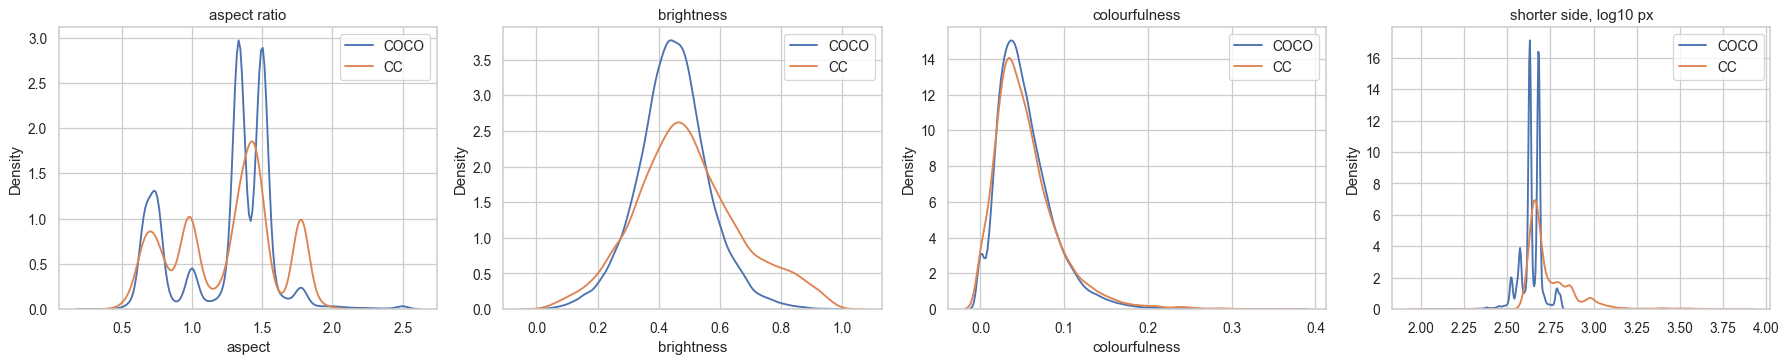

,COCO,CC
metric,,
Images analysed,40494,10038
Distinct sizes,1534,3340
Median width × height,640 × 480,640 × 494
Grayscale share,0.00163,0.006376
Landscape share,0.717,0.639
Mean brightness,0.447675,0.496227
Mean colourfulness,0.053448,0.054748
"Pixel mean R,G,B","[0.4682, 0.4451, 0.4063]","[0.5238, 0.499, 0.4692]"
"Pixel std R,G,B","[0.2693, 0.2645, 0.2794]","[0.3088, 0.3024, 0.3145]"


In [20]:
coco_info_ok = coco_info[coco_info.ok]
fig, ax = plt.subplots(1, 4, figsize=(20, 4.2))
for d, lbl, c in [(coco_info_ok, "COCO", "#4C72B0"), (ok, "CC", "#DD8452")]:
    sns.kdeplot(d.aspect.clip(0.3, 2.5), ax=ax[0], label=lbl, color=c, common_norm=False)
    sns.kdeplot(d.brightness, ax=ax[1], label=lbl, color=c)
    sns.kdeplot(d.colourfulness, ax=ax[2], label=lbl, color=c)
    sns.kdeplot(np.log10(d[["width", "height"]].min(axis=1)), ax=ax[3], label=lbl, color=c)
ax[0].set(title="aspect ratio"); ax[1].set(title="brightness"); ax[2].set(title="colourfulness")
ax[3].set(title="shorter side, log10 px")
for a in ax:
    a.legend()
plt.tight_layout(); savefig("coco_vs_cc_images"); plt.show()

cr = coco_raw_sum["images"]
VS_IMG = pd.DataFrame([
    ("Images analysed", len(coco_info_ok), len(ok)),
    ("Distinct sizes", cr["distinct_sizes"], IMG_RAW["distinct_sizes"]),
    ("Median width × height", f"{coco_info_ok.width.median():.0f} × {coco_info_ok.height.median():.0f}", f"{IMG_RAW['median_width']:.0f} × {IMG_RAW['median_height']:.0f}"),
    ("Grayscale share", cr["grayscale"] / len(coco_info_ok), IMG_RAW["grayscale"] / len(ok)),
    ("Landscape share", cr["orientation"].get("landscape", 0), IMG_RAW["orientation"].get("landscape", 0)),
    ("Mean brightness", float(coco_info_ok.brightness.mean()), IMG_RAW["brightness_mean"]),
    ("Mean colourfulness", float(coco_info_ok.colourfulness.mean()), IMG_RAW["colourfulness_mean"]),
    ("Pixel mean R,G,B", str(cr["pixel_mean"]), str(IMG_RAW["pixel_mean"])),
    ("Pixel std R,G,B", str(cr["pixel_std"]), str(IMG_RAW["pixel_std"])),
], columns=["metric", "COCO", "CC"]).set_index("metric")
VS_IMG

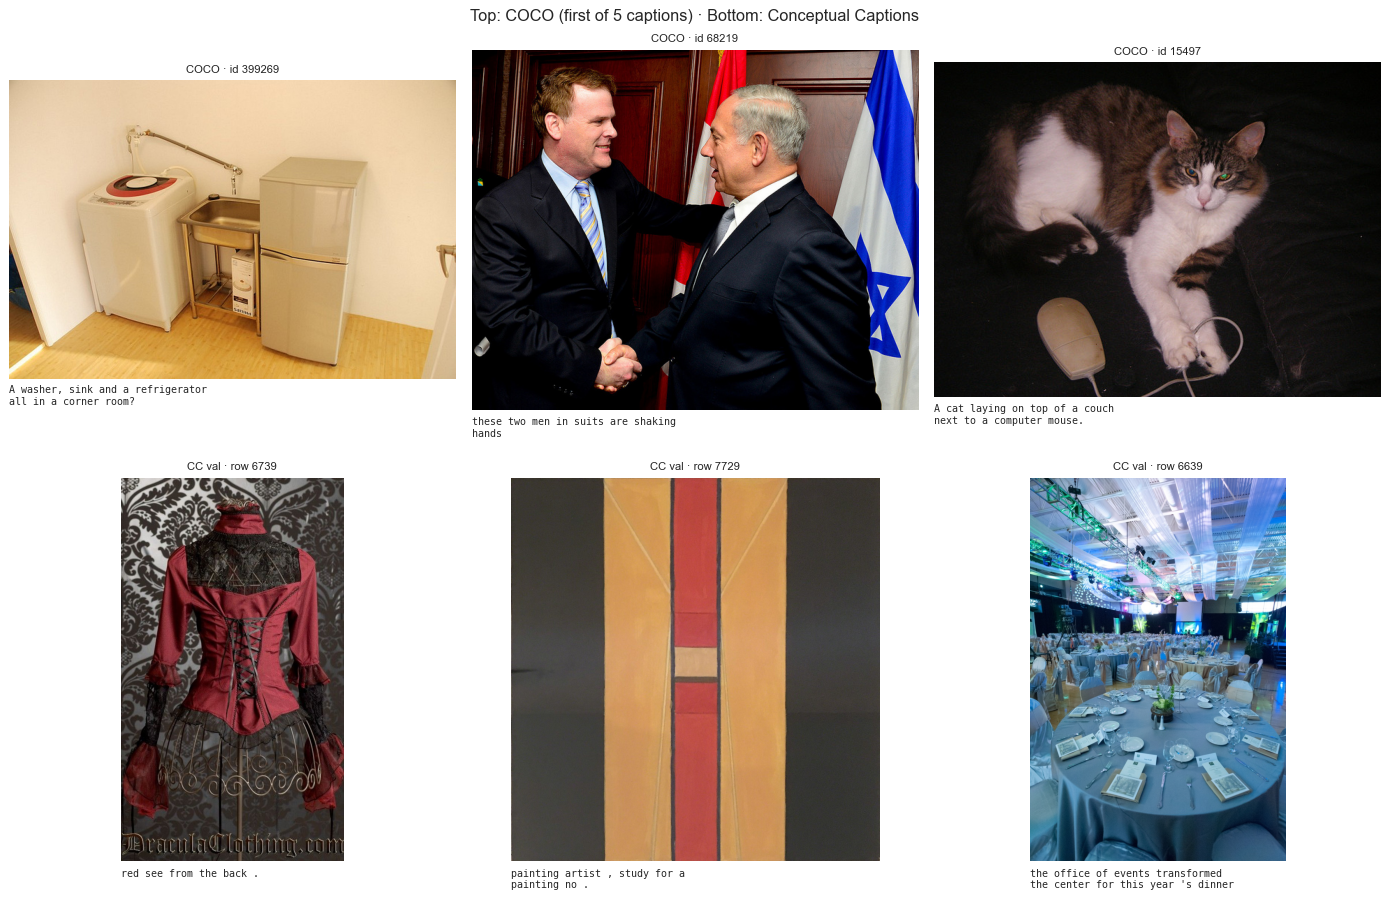

In [21]:
coco_recs = json.load(open(COCO / "train" / "captions.json", encoding="utf-8"))
items = [(COCO / "train" / "images" / r["image"], f"COCO · id {r['cocoid']}", textwrap.fill(r["captions"][0], 34))
         for r in random.Random(SEED).sample(coco_recs, 3)]
items += [cc_item(r, cap_of[r]) for r in got.sample(3, random_state=SEED + 1).row]
show_images(items, 3, "coco_vs_cc_samples", "Top: COCO (first of 5 captions) · Bottom: Conceptual Captions", text_lines=4)

## Save all numbers

In [22]:
def jsonable(d):
    return {k: v for k, v in d.items() if isinstance(v, (int, float, str, bool, list, dict)) or v is None}

json.dump({"download": DL, "text": jsonable(S_raw), "paper_check": PAPER.to_dict(), "cc_specific": CC_SPECIFIC, "images": IMG_RAW},
          open(ROOT / "eda" / "cc_summary_raw.json", "w"), indent=1, default=float)
json.dump({"text": jsonable(S_clean), "images": IMG_CLEAN, "preprocessing_steps": STEP_LOG.to_dict("records"),
           "vocab": {"size_with_specials": len(itos), "min_freq": MIN_FREQ, "coverage": cov, "full_train_clean_types": len(vocab_counts)},
           "max_len": MAX_LEN, "p99_len_full_train": p99, "truncated_share": trunc, "no_flip_rows": len(NO_FLIP),
           "coco_vs_cc": VS.astype(str).to_dict()["CC"], "coco_vs_cc_coco": VS.astype(str).to_dict()["COCO"],
           "distinctive_words": DISTINCT, "oov": {"cc_val_in_coco_vocab_tokens": cc_in_coco_tok, "cc_val_in_coco_vocab_captions": cc_in_coco_cap,
                                                  "coco_val_in_cc_vocab_tokens": coco_in_cc_tok, "coco_val_in_cc_vocab_captions": coco_in_cc_cap,
                                                  "cc_val_in_cc_vocab_tokens": cc_in_cc_tok, "cc_val_in_cc_vocab_captions": cc_in_cc_cap,
                                                  "coco_val_in_coco_vocab_tokens": coco_in_coco_tok, "coco_val_in_coco_vocab_captions": coco_in_coco_cap}},
          open(ROOT / "eda" / "cc_summary_clean.json", "w"), indent=1, default=float)
print("saved eda/cc_summary_raw.json, eda/cc_summary_clean.json, eda/cc_comparison.csv, eda/coco_vs_cc.csv")

saved eda/cc_summary_raw.json, eda/cc_summary_clean.json, eda/cc_comparison.csv, eda/coco_vs_cc.csv
